In [2]:
import tensorflow as tf

train_dir = "/kaggle/input/datasets/divvelaramasaianuhya/naturalist/inaturalist_12K/train"
test_dir = "/kaggle/input/datasets/divvelaramasaianuhya/naturalist/inaturalist_12K/val"


2026-06-28 11:08:50.048380: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782644930.230048      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782644930.280647      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782644930.720010      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782644930.720046      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782644930.720048      58 computation_placer.cc:177] computation placer alr

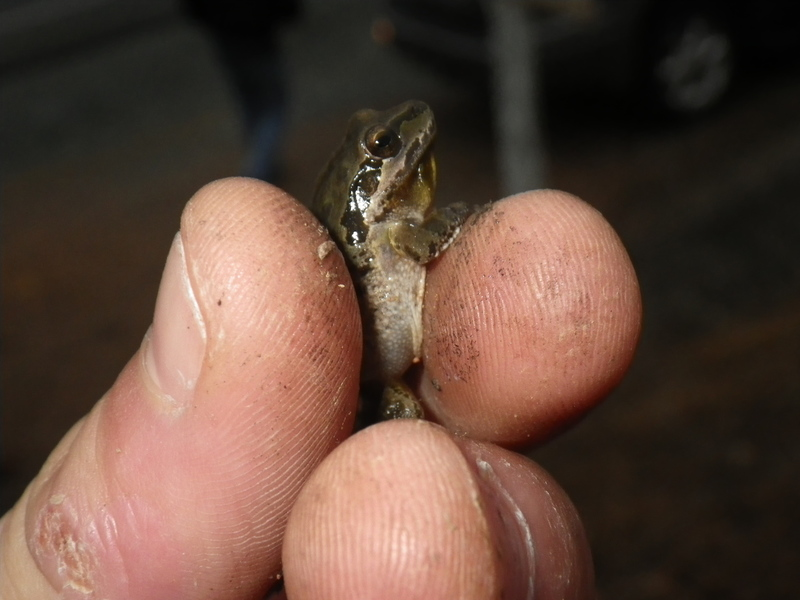

In [3]:
import PIL
import PIL.Image
from pathlib import Path 

data_dir = Path('/kaggle/input/datasets/divvelaramasaianuhya/naturalist/inaturalist_12K/train')

Amphibia = list(data_dir.glob('**/Amphibia/*'))

PIL.Image.open(str(Amphibia[0]))




In [4]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers

IMG_SIZE = (227,227)
BATCH = 32

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.2),
  layers.RandomBrightness(0.2),
  layers.RandomContrast(0.2)
])

# 1. Training Subset
train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.1,    
    subset='training',
    seed=123,               
    image_size=IMG_SIZE,
    batch_size=32
)

# 2. Validation Subset
val_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.1,
    subset='validation',
    seed=123,               
    image_size=IMG_SIZE,
    batch_size=32
)

# 3. Test dataset
test_ds = image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=32
)


I0000 00:00:1782644991.070894      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 9999 files belonging to 10 classes.
Using 9000 files for training.
Found 9999 files belonging to 10 classes.
Using 999 files for validation.
Found 2000 files belonging to 10 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


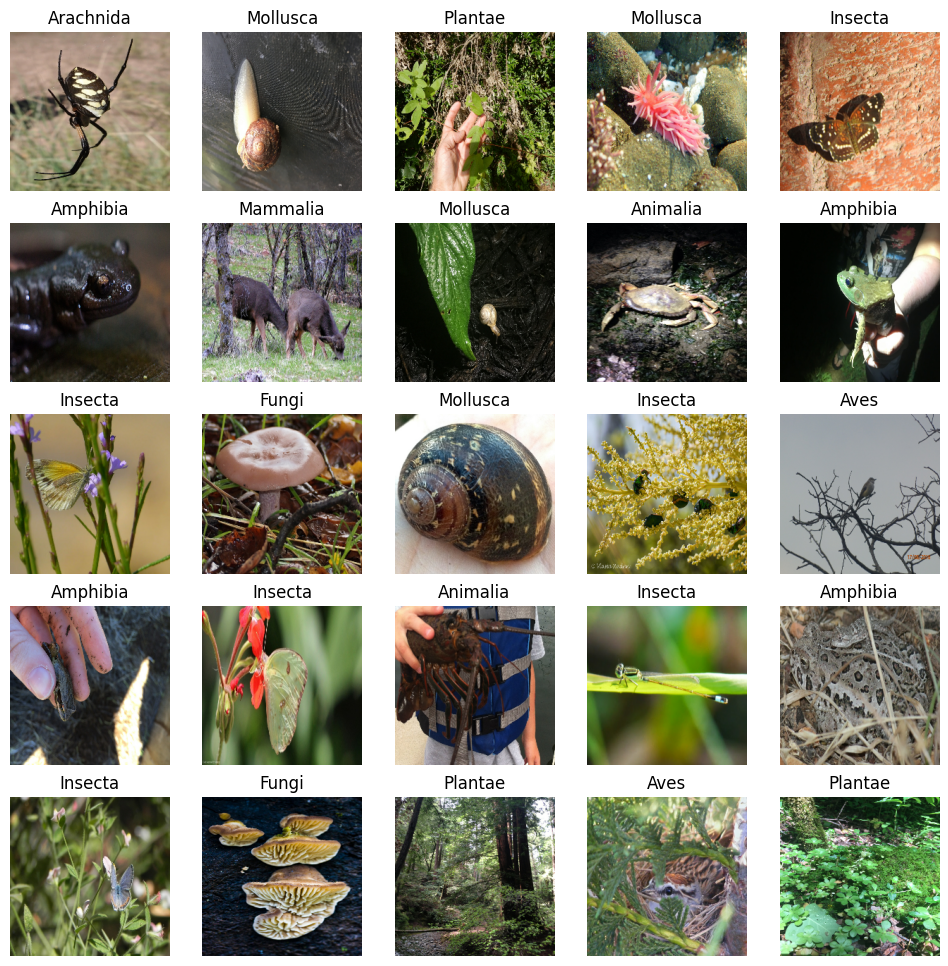

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
  for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

In [6]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 227, 227, 3)
(32, 10)


In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.callbacks import EarlyStopping

def create_inat_model(num_classes=10, input_shape=(227, 227, 3)):
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),
        data_augmentation,
        normalization_layer,
        
        # Block 1: Low-level features
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(512, kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Activation("relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax') 
    ])
    return model

# Instantiate the model
model = create_inat_model()


In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 227, 227, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 227, 227, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 227, 227, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 227, 227, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 227, 227, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 227, 227, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 113, 113, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 113, 113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 113, 113, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 113, 113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 2,034,986 (7.76 MB)

 Trainable params: 2,032,554 (7.75 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/60


I0000 00:00:1782641693.825492     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 204ms/step - accuracy: 0.1758 - loss: 2.6409 - val_accuracy: 0.2322 - val_loss: 2.4775 - learning_rate: 0.0010
Epoch 2/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 172ms/step - accuracy: 0.2129 - loss: 2.4608 - val_accuracy: 0.2122 - val_loss: 2.4450 - learning_rate: 0.0010
Epoch 3/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 172ms/step - accuracy: 0.2211 - loss: 2.4070 - val_accuracy: 0.1852 - val_loss: 2.4288 - learning_rate: 0.0010
Epoch 4/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 172ms/step - accuracy: 0.2311 - loss: 2.3513 - val_accuracy: 0.2643 - val_loss: 2.3031 - learning_rate: 0.0010
Epoch 5/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - accuracy: 0.2367 - loss: 2.3045 - val_accuracy: 0.2432 - val_loss: 2.2827 - learning_rate: 0.0010
Epoch 6/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - accuracy: 0.2400 - loss: 2.2641 - val_accuracy: 0.2523 - val_loss: 2.2259 - learning_rate: 0.0010
Epoch 7/60
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - accuracy: 0.2446 - loss:

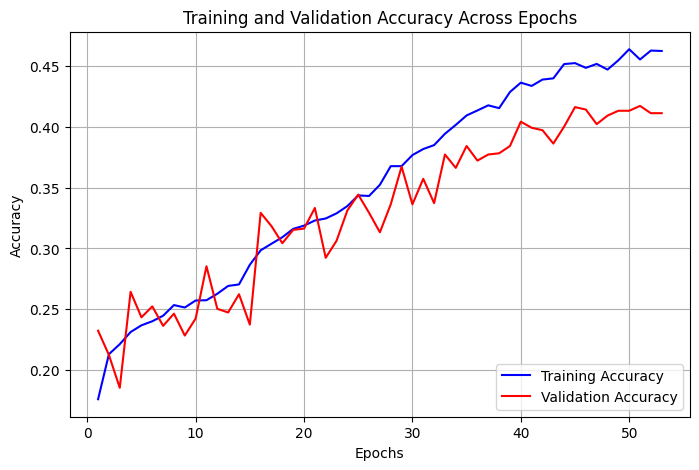

In [12]:
import matplotlib.pyplot as plt

training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1, len(training_accuracy) + 1)


plt.figure(figsize=(8, 5))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy Across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [13]:
loss, acc = model.evaluate(test_ds)

print(acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.4050 - loss: 1.8345
0.4050000011920929
